In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np

file_name = list(uploaded.keys())[0]
print("Đã upload file:", file_name)

df = pd.read_excel(file_name)
df.head()


Saving clean_pivot.xlsx to clean_pivot.xlsx
Đã upload file: clean_pivot.xlsx


,REF_AREA_LABEL,Year,GDP (current US$),"Population, total"
0,Brunei Darussalam,1960,NaN,88347
1,Brunei Darussalam,1961,NaN,92517
2,Brunei Darussalam,1962,NaN,96719
3,Brunei Darussalam,1963,NaN,101159
4,Brunei Darussalam,1964,NaN,105922


PCA

In [ ]:
# Giữ cột cần thiết
cols = ["REF_AREA_LABEL", "Year", "GDP (current US$)", "Population, total"]
df_pca = df[cols].copy()

# Loại dòng bị NA
df_pca = df_pca.dropna(subset=["GDP (current US$)", "Population, total"])

print("Số dòng sau khi làm sạch:", len(df_pca))
df_pca.head()


Số dòng sau khi làm sạch: 574


,REF_AREA_LABEL,Year,GDP (current US$),"Population, total"
5,Brunei Darussalam,1965,114039500.6,110838
6,Brunei Darussalam,1966,132757528.0,115874
7,Brunei Darussalam,1967,139029537.2,121017
8,Brunei Darussalam,1968,160818235.9,126222
9,Brunei Darussalam,1969,161210236.4,131446


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Lấy 2 biến số
features = ["GDP (current US$)", "Population, total"]
X = df_pca[features].values

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 2 thành phần
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Thêm PC1, PC2 vào dataframe
df_pca["PC1"] = X_pca[:, 0]
df_pca["PC2"] = X_pca[:, 1]

# In thông tin PCA
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Components (weights):")
print(pca.components_)

df_pca.head()


Explained variance ratio: [0.83251524 0.16748476]
Components (weights):
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


,REF_AREA_LABEL,Year,GDP (current US$),"Population, total",PC1,PC2
5,Brunei Darussalam,1965,114039500.6,110838,-0.947576,-0.175509
6,Brunei Darussalam,1966,132757528.0,115874,-0.947452,-0.175516
7,Brunei Darussalam,1967,139029537.2,121017,-0.947370,-0.175478
8,Brunei Darussalam,1968,160818235.9,126222,-0.947233,-0.175494
9,Brunei Darussalam,1969,161210236.4,131446,-0.947170,-0.175435


In [ ]:
# Perform PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# Giữ lại cột số để PCA
df_numeric = df[["GDP (current US$)", "Population, total"]].dropna()

# Scale the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

# Apply PCA
pca = PCA()   # full components cho 2 biến = 2 PCs
pca.fit(df_scaled)

pca_components = pca.transform(df_scaled)

# Print explained variance ratio
print("Explained variance ratio of each principal component:")
print(pca.explained_variance_ratio_)


Explained variance ratio of each principal component:
[0.83251524 0.16748476]


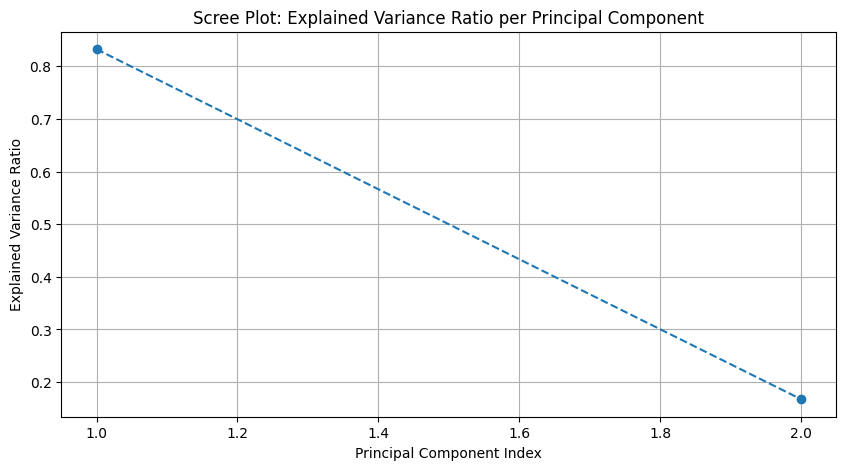

In [ ]:
# Plot PCA results
import matplotlib.pyplot as plt

# ---- Scree Plot ----
plt.figure(figsize=(10,5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_, marker='o', linestyle='--')

plt.title('Scree Plot: Explained Variance Ratio per Principal Component')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()


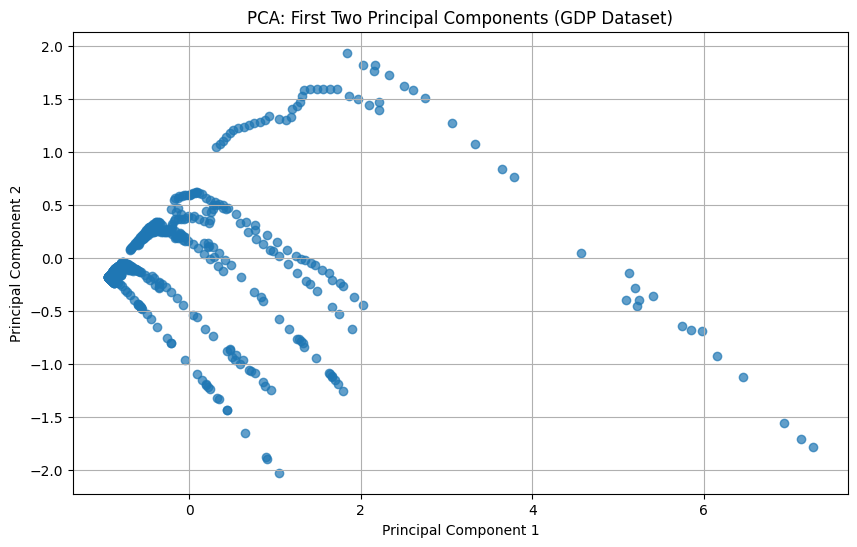

In [ ]:
# ---- Plot the first two principal components ----
plt.figure(figsize=(10,6))

plt.scatter(pca_components[:, 0], pca_components[:, 1], alpha=0.7)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: First Two Principal Components (GDP Dataset)')
plt.grid(True)
plt.show()


In [ ]:
# Perform Clustering
from sklearn.cluster import KMeans

# Khởi tạo KMeans với 3 cụm (có thể đổi n_clusters nếu muốn)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')

# Fit mô hình
kmeans.fit(pca_components)

# Gán nhãn cluster cho từng điểm
cluster = kmeans.predict(pca_components)

print("Cluster labels generated:")
print(cluster)


Cluster labels generated:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 2 0 0 0 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0

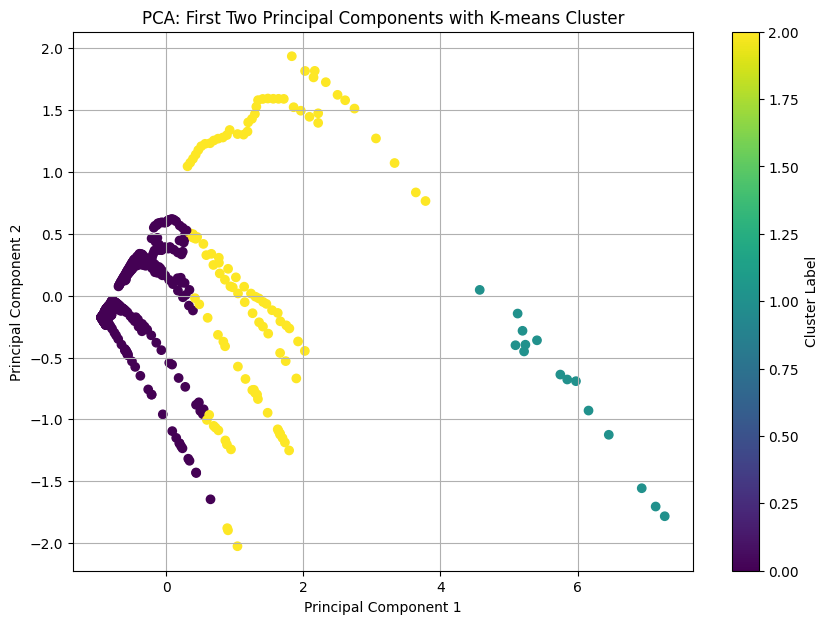

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    pca_components[:, 0],
    pca_components[:, 1],
    c=cluster,
    cmap='viridis'
)

plt.title('PCA: First Two Principal Components with K-means Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

cbar = plt.colorbar(scatter, label='Cluster Label')
plt.grid(True)
plt.show()


In [ ]:
def forecast_gdp_cagr(group,
                      start_year=2015,
                      end_year=2024,
                      future_start=2025,
                      future_end=2030):
    """
    group: DataFrame của 1 quốc gia (REF_AREA_LABEL)
    Trả về: DataFrame chứa GDP_forecast 2025–2030
    """
    country = group["REF_AREA_LABEL"].iloc[0]

    g = group[(group["Year"] >= start_year) & (group["Year"] <= end_year)].copy()
    g = g.dropna(subset=["GDP (current US$)"])

    if g.empty or (g["Year"].min() > start_year) or (g["Year"].max() < end_year):
        print(f"[WARNING] {country}: không đủ dữ liệu {start_year}-{end_year} để tính CAGR.")
        return pd.DataFrame()

    g = g.set_index("Year")
    gdp_start = g.loc[start_year, "GDP (current US$)"]
    gdp_end   = g.loc[end_year,   "GDP (current US$)"]

    n_years = end_year - start_year
    cagr = (gdp_end / gdp_start) ** (1 / n_years) - 1

    rows = []
    for year in range(future_start, future_end + 1):
        gdp_year = gdp_end * ((1 + cagr) ** (year - end_year))
        rows.append({
            "REF_AREA_LABEL": country,
            "Year": year,
            "GDP_forecast": gdp_year,
            "CAGR_2015_2024": cagr
        })

    return pd.DataFrame(rows)



In [ ]:
forecast_list = []

for country, group in df.groupby("REF_AREA_LABEL"):
    f = forecast_gdp_cagr(group)
    if not f.empty:
        forecast_list.append(f)

df_fc = pd.concat(forecast_list, ignore_index=True)
df_fc.head()


,REF_AREA_LABEL,Year,GDP_forecast,CAGR_2015_2024
0,Brunei Darussalam,2025,1.577356e+10,0.020075
1,Brunei Darussalam,2026,1.609021e+10,0.020075
2,Brunei Darussalam,2027,1.641322e+10,0.020075
3,Brunei Darussalam,2028,1.674272e+10,0.020075
4,Brunei Darussalam,2029,1.707883e+10,0.020075


In [ ]:
from IPython.display import HTML
HTML(df_fc.to_html(index=False))


REF_AREA_LABEL,Year,GDP_forecast,CAGR_2015_2024
Brunei Darussalam,2025,1.577356e+10,0.020075
Brunei Darussalam,2026,1.609021e+10,0.020075
Brunei Darussalam,2027,1.641322e+10,0.020075
Brunei Darussalam,2028,1.674272e+10,0.020075
Brunei Darussalam,2029,1.707883e+10,0.020075
Brunei Darussalam,2030,1.742169e+10,0.020075
Cambodia,2025,4.982969e+10,0.075013
Cambodia,2026,5.356756e+10,0.075013
Cambodia,2027,5.758582e+10,0.075013
Cambodia,2028,6.190549e+10,0.075013


In [ ]:
last_actual_year = df["Year"].max()   # trong file là 2024

# Chỉ lấy các dòng forecast > last_actual_year
df_fc_future = df_fc[df_fc["Year"] > last_actual_year].copy()

# Tạo các cột giống df gốc, để concat được
df_fc_future["GDP (current US$)"] = np.nan
df_fc_future["Population, total"] = np.nan

# Ghép: dữ liệu thật (1960–2024) + forecast (2025–2030)
df_all = pd.concat([df, df_fc_future], ignore_index=True)

# Tạo GDP_final: nếu có GDP thật thì dùng, không thì dùng forecast
df_all["GDP_final"] = df_all["GDP (current US$)"]
df_all.loc[df_all["GDP_final"].isna(), "GDP_final"] = df_all["GDP_forecast"]

df_all["GDP_final_billion"] = df_all["GDP_final"] / 1e9

df_all.tail(15)


,REF_AREA_LABEL,Year,GDP (current US$),"Population, total",GDP_forecast,CAGR_2015_2024,GDP_final,GDP_final_billion
695,Singapore,2028,NaN,NaN,7.060705e+11,0.065897,7.060705e+11,706.070459
696,Singapore,2029,NaN,NaN,7.525983e+11,0.065897,7.525983e+11,752.598279
697,Singapore,2030,NaN,NaN,8.021921e+11,0.065897,8.021921e+11,802.192135
698,Thailand,2025,NaN,NaN,5.420998e+11,0.030608,5.420998e+11,542.099779
699,Thailand,2026,NaN,NaN,5.586923e+11,0.030608,5.586923e+11,558.692338
700,Thailand,2027,NaN,NaN,5.757928e+11,0.030608,5.757928e+11,575.792762
701,Thailand,2028,NaN,NaN,5.934166e+11,0.030608,5.934166e+11,593.416595
702,Thailand,2029,NaN,NaN,6.115799e+11,0.030608,6.115799e+11,611.579857
703,Thailand,2030,NaN,NaN,6.302991e+11,0.030608,6.302991e+11,630.299059
704,Viet Nam,2025,NaN,NaN,5.138690e+11,0.079557,5.138690e+11,513.868981


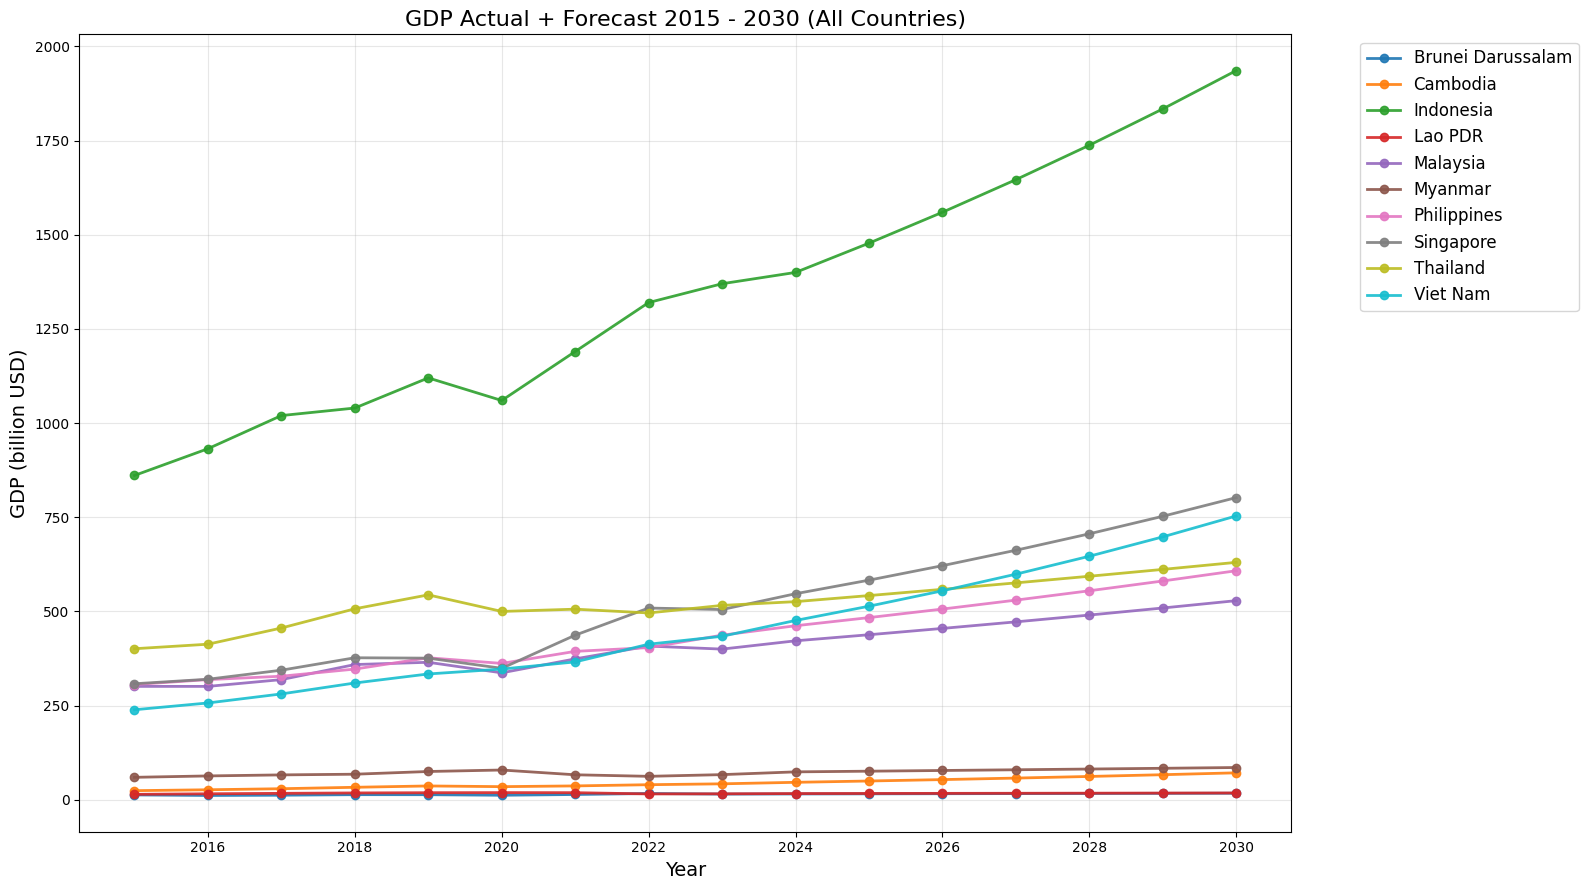

In [ ]:
import matplotlib.pyplot as plt

# Lấy danh sách toàn bộ các quốc gia
countries = sorted(df_all["REF_AREA_LABEL"].unique())

# Lọc phạm vi năm
plot_df = df_all[(df_all["Year"] >= 2015) & (df_all["Year"] <= 2030)]

plt.figure(figsize=(16, 9))

# Vẽ line cho từng nước
for country in countries:
    sub = plot_df[plot_df["REF_AREA_LABEL"] == country]
    plt.plot(
        sub["Year"],
        sub["GDP_final_billion"],
        marker='o',
        linewidth=2,
        alpha=0.9,
        label=country
    )

plt.title("GDP Actual + Forecast 2015 - 2030 (All Countries)", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("GDP (billion USD)", fontsize=14)
plt.grid(alpha=0.3)

# đặt legend bên phải cho gọn
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=12)

plt.tight_layout()
plt.show()
